# Airline Case Study — Python + CSV

## Business Case

### Our airline is facing pressure from higher fuel costs, labour costs, taxes, financing costs and stricter environmental requirements.

### The business wants to improve **seat occupancy** and **revenue per available seat** so that unused capacity is reduced.

## 1. Loading the CSV Files

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import json

In [4]:
aircrafts = pd.read_csv("aircrafts_data.csv")
airports = pd.read_csv("airports_data.csv")
boarding = pd.read_csv("boarding_passes.csv")
bookings = pd.read_csv("bookings.csv")
flights = pd.read_csv("flights.csv")
seats = pd.read_csv("seats.csv")
ticket_flights = pd.read_csv("ticket_flights.csv")
tickets = pd.read_csv("tickets.csv")

## 2. Understanding the Tables Before Coding

In [3]:
print("aircrafts:", aircrafts.columns)
print("airports:", airports.columns)
print("boarding:", boarding.columns)
print("bookings:", bookings.columns)
print("flights:", flights.columns)
print("seats:", seats.columns)
print("ticket_flights:", ticket_flights.columns)
print("tickets:", tickets.columns)

aircrafts: Index(['aircraft_code', 'model', 'range'], dtype='str')
airports: Index(['airport_code', 'airport_name', 'city', 'coordinates', 'timezone'], dtype='str')
boarding: Index(['ticket_no', 'flight_id', 'boarding_no', 'seat_no'], dtype='str')
bookings: Index(['book_ref', 'book_date', 'total_amount'], dtype='str')
flights: Index(['flight_id', 'flight_no', 'scheduled_departure', 'scheduled_arrival',
       'departure_airport', 'arrival_airport', 'status', 'aircraft_code',
       'actual_departure', 'actual_arrival'],
      dtype='str')
seats: Index(['aircraft_code', 'seat_no', 'fare_conditions'], dtype='str')
ticket_flights: Index(['ticket_no', 'flight_id', 'fare_conditions', 'amount'], dtype='str')
tickets: Index(['ticket_no', 'book_ref', 'passenger_id'], dtype='str')


The dataset contains eight CSV files.

| Table | One row represents | Main columns |
|---|---|---|
| `aircrafts_data.csv` | one aircraft type | aircraft_code, model, range |
| `airports_data.csv` | one airport | airport_code, airport_name, city, coordinates, timezone |
| `flights.csv` | one scheduled flight | flight_id, flight_no, scheduled_departure, scheduled_arrival, departure_airport, arrival_airport, status, aircraft_code, actual_departure, actual_arrival |
| `seats.csv` | one seat in an aircraft type | aircraft_code, seat_no, fare_conditions |
| `boarding_passes.csv` | one boarding record | ticket_no, flight_id, boarding_no, seat_no |
| `tickets.csv` | one ticket | ticket_no, book_ref, passenger_id |
| `ticket_flights.csv` | one ticket on one flight | ticket_no, flight_id, fare_conditions, amount |
| `bookings.csv` | one booking | book_ref, book_date, total_amount |

## 3. First Looking at the Data

- shape
- first few rows
- data types
- missing values
- duplicates

In [5]:
print("aircrafts:", aircrafts.shape)
print("airports:", airports.shape)
print("boarding:", boarding.shape)
print("bookings:", bookings.shape)
print("flights:", flights.shape)
print("seats:", seats.shape)
print("ticket_flights:", ticket_flights.shape)
print("tickets:", tickets.shape)

aircrafts: (9, 3)
airports: (104, 5)
boarding: (579686, 4)
bookings: (262788, 3)
flights: (33121, 10)
seats: (1339, 3)
ticket_flights: (1045726, 4)
tickets: (366733, 3)


In [6]:
aircrafts.head()

,aircraft_code,model,range
0,773,"{""en"": ""Boeing 777-300"", ""ru"": ""Боинг 777-300""}",11100
1,763,"{""en"": ""Boeing 767-300"", ""ru"": ""Боинг 767-300""}",7900
2,SU9,"{""en"": ""Sukhoi Superjet-100"", ""ru"": ""Сухой Суп...",3000
3,320,"{""en"": ""Airbus A320-200"", ""ru"": ""Аэробус A320-...",5700
4,321,"{""en"": ""Airbus A321-200"", ""ru"": ""Аэробус A321-...",5600


In [7]:
airports.head()

,airport_code,airport_name,city,coordinates,timezone
0,YKS,"{""en"": ""Yakutsk Airport"", ""ru"": ""Якутск""}","{""en"": ""Yakutsk"", ""ru"": ""Якутск""}","(129.77099609375,62.0932998657226562)",Asia/Yakutsk
1,MJZ,"{""en"": ""Mirny Airport"", ""ru"": ""Мирный""}","{""en"": ""Mirnyj"", ""ru"": ""Мирный""}","(114.03900146484375,62.534698486328125)",Asia/Yakutsk
2,KHV,"{""en"": ""Khabarovsk-Novy Airport"", ""ru"": ""Хабар...","{""en"": ""Khabarovsk"", ""ru"": ""Хабаровск""}","(135.18800354004,48.5279998779300001)",Asia/Vladivostok
3,PKC,"{""en"": ""Yelizovo Airport"", ""ru"": ""Елизово""}","{""en"": ""Petropavlovsk"", ""ru"": ""Петропавловск-К...","(158.453994750976562,53.1679000854492188)",Asia/Kamchatka
4,UUS,"{""en"": ""Yuzhno-Sakhalinsk Airport"", ""ru"": ""Хом...","{""en"": ""Yuzhno-Sakhalinsk"", ""ru"": ""Южно-Сахали...","(142.718002319335938,46.8886985778808594)",Asia/Sakhalin


In [8]:
boarding.head()

,ticket_no,flight_id,boarding_no,seat_no
0,5435212351,30625,1,2D
1,5435212386,30625,2,3G
2,5435212381,30625,3,4H
3,5432211370,30625,4,5D
4,5435212357,30625,5,11A


In [9]:
bookings.head()

,book_ref,book_date,total_amount
0,00000F,2017-07-05 03:12:00+03,265700
1,000012,2017-07-14 09:02:00+03,37900
2,000068,2017-08-15 14:27:00+03,18100
3,000181,2017-08-10 13:28:00+03,131800
4,0002D8,2017-08-07 21:40:00+03,23600


In [10]:
flights.head()

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival
0,1185,PG0134,2017-09-10 09:50:00+03,2017-09-10 14:55:00+03,DME,BTK,Scheduled,319,\N,\N
1,3979,PG0052,2017-08-25 14:50:00+03,2017-08-25 17:35:00+03,VKO,HMA,Scheduled,CR2,\N,\N
2,4739,PG0561,2017-09-05 12:30:00+03,2017-09-05 14:15:00+03,VKO,AER,Scheduled,763,\N,\N
3,5502,PG0529,2017-09-12 09:50:00+03,2017-09-12 11:20:00+03,SVO,UFA,Scheduled,763,\N,\N
4,6938,PG0461,2017-09-04 12:25:00+03,2017-09-04 13:20:00+03,SVO,ULV,Scheduled,SU9,\N,\N


In [11]:
seats.head()

,aircraft_code,seat_no,fare_conditions
0,319,2A,Business
1,319,2C,Business
2,319,2D,Business
3,319,2F,Business
4,319,3A,Business


In [12]:
ticket_flights.head()

,ticket_no,flight_id,fare_conditions,amount
0,5432159776,30625,Business,42100
1,5435212351,30625,Business,42100
2,5435212386,30625,Business,42100
3,5435212381,30625,Business,42100
4,5432211370,30625,Business,42100


In [13]:
tickets.head()

,ticket_no,book_ref,passenger_id
0,5432000987,06B046,8149 604011
1,5432000988,06B046,8499 420203
2,5432000989,E170C3,1011 752484
3,5432000990,E170C3,4849 400049
4,5432000991,F313DD,6615 976589


In [15]:
aircrafts.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   aircraft_code  9 non-null      str  
 1   model          9 non-null      str  
 2   range          9 non-null      int64
dtypes: int64(1), str(2)
memory usage: 910.0 bytes


In [16]:
airports.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   airport_code  104 non-null    str  
 1   airport_name  104 non-null    str  
 2   city          104 non-null    str  
 3   coordinates   104 non-null    str  
 4   timezone      104 non-null    str  
dtypes: str(5)
memory usage: 20.4 KB


In [17]:
boarding.info()

<class 'pandas.DataFrame'>
RangeIndex: 579686 entries, 0 to 579685
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   ticket_no    579686 non-null  int64
 1   flight_id    579686 non-null  int64
 2   boarding_no  579686 non-null  int64
 3   seat_no      579686 non-null  str  
dtypes: int64(3), str(1)
memory usage: 19.2 MB


In [18]:
bookings.info()

<class 'pandas.DataFrame'>
RangeIndex: 262788 entries, 0 to 262787
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   book_ref      262788 non-null  str  
 1   book_date     262788 non-null  str  
 2   total_amount  262788 non-null  int64
dtypes: int64(1), str(2)
memory usage: 13.0 MB


In [19]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 33121 entries, 0 to 33120
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   flight_id            33121 non-null  int64
 1   flight_no            33121 non-null  str  
 2   scheduled_departure  33121 non-null  str  
 3   scheduled_arrival    33121 non-null  str  
 4   departure_airport    33121 non-null  str  
 5   arrival_airport      33121 non-null  str  
 6   status               33121 non-null  str  
 7   aircraft_code        33121 non-null  str  
 8   actual_departure     33121 non-null  str  
 9   actual_arrival       33121 non-null  str  
dtypes: int64(1), str(9)
memory usage: 5.4 MB


In [20]:
seats.info()

<class 'pandas.DataFrame'>
RangeIndex: 1339 entries, 0 to 1338
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   aircraft_code    1339 non-null   str  
 1   seat_no          1339 non-null   str  
 2   fare_conditions  1339 non-null   str  
dtypes: str(3)
memory usage: 48.3 KB


In [21]:
ticket_flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 1045726 entries, 0 to 1045725
Data columns (total 4 columns):
 #   Column           Non-Null Count    Dtype
---  ------           --------------    -----
 0   ticket_no        1045726 non-null  int64
 1   flight_id        1045726 non-null  int64
 2   fare_conditions  1045726 non-null  str  
 3   amount           1045726 non-null  int64
dtypes: int64(3), str(1)
memory usage: 39.0 MB


In [22]:
tickets.info()

<class 'pandas.DataFrame'>
RangeIndex: 366733 entries, 0 to 366732
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   ticket_no     366733 non-null  int64
 1   book_ref      366733 non-null  str  
 2   passenger_id  366733 non-null  str  
dtypes: int64(1), str(2)
memory usage: 14.3 MB


**Which table contains aircraft capacity information?**

`seats.csv`. Each row represents one seat for an aircraft type. Counting rows by `aircraft_code` gives the available seat capacity.

**Which table tells us how many passengers boarded a flight?**

`boarding_passes.csv`. Each boarding record represents a passenger boarding assignment for a flight. Grouping by `flight_id` gives the boarded-passenger count used for occupancy analysis.

**Which table contains ticket revenue?**

`ticket_flights.csv`. The `amount` column is the ticket/fare amount for a ticket on a flight.

**Which table contains booking date?**

`bookings.csv`, using `book_date`.

## 4. Missing Values and Data Quality

The source data contains `\N` as a missing-value placeholder. So need to convert it into a proper missing value.

In [23]:
aircrafts = aircrafts.replace(r"\N", pd.NA)
airports = airports.replace(r"\N", pd.NA)
boarding = boarding.replace(r"\N", pd.NA)
bookings = bookings.replace(r"\N", pd.NA)
flights = flights.replace(r"\N", pd.NA)
seats = seats.replace(r"\N", pd.NA)
ticket_flights = ticket_flights.replace(r"\N", pd.NA)
tickets = tickets.replace(r"\N", pd.NA)

In [25]:
print("Missing values in flights : ")
print(flights.isnull().sum())

Missing values in flights : 
flight_id                  0
flight_no                  0
scheduled_departure        0
scheduled_arrival          0
departure_airport          0
arrival_airport            0
status                     0
aircraft_code              0
actual_departure       16348
actual_arrival         16406
dtype: int64


for actual departure and actual arrival almost 50-55% data is missing.

In [26]:
print("Missing values in bookings")
print(bookings.isnull().sum())

Missing values in bookings
book_ref        0
book_date       0
total_amount    0
dtype: int64


In [27]:
print("Missing values in ticket_flights")
print(ticket_flights.isnull().sum())

Missing values in ticket_flights
ticket_no          0
flight_id          0
fare_conditions    0
amount             0
dtype: int64


## 5. Checking Duplicates

In [28]:
print("Duplicate flight IDs:", flights["flight_id"].duplicated().sum())
print("Duplicate ticket numbers:", tickets["ticket_no"].duplicated().sum())
print("Duplicate seat rows:", seats.duplicated(["aircraft_code", "seat_no"]).sum())

Duplicate flight IDs: 0
Duplicate ticket numbers: 0
Duplicate seat rows: 0


got 0, which means no duplicates present in the data. So no need to do anything.

## 6. Converting Columns to the Correct Data Type

In [30]:
flights["scheduled_departure"] = pd.to_datetime(flights["scheduled_departure"], errors="coerce")
flights["scheduled_arrival"] = pd.to_datetime(flights["scheduled_arrival"], errors="coerce")
flights["actual_departure"] = pd.to_datetime(flights["actual_departure"], errors="coerce")
flights["actual_arrival"] = pd.to_datetime(flights["actual_arrival"], errors="coerce")
bookings["book_date"] = pd.to_datetime(bookings["book_date"], errors="coerce")

## 7. Cleaning the JSON-like Text Columns

Some columns contain values such as:

`{"en": "Boeing 777-300", "ru": "..."}`

I need only the English value. Need to clean and create a column only in english

In [32]:
def get_english_name(value):
    if pd.isna(value):
        return value
    return json.loads(value)["en"]

aircrafts["model"] = aircrafts["model"].apply(get_english_name)
airports["airport_name"] = airports["airport_name"].apply(get_english_name)
airports["city"] = airports["city"].apply(get_english_name)

aircrafts.head()

,aircraft_code,model,range
0,773,Boeing 777-300,11100
1,763,Boeing 767-300,7900
2,SU9,Sukhoi Superjet-100,3000
3,320,Airbus A320-200,5700
4,321,Airbus A321-200,5600


Cleaning improves interpretability. The analysis can be technically correct with the raw JSON, but business users cannot easily understand the result. Readable labels make charts and tables easier to communicate.

## 8. Saving the Cleaned CSV Files

Once the cleaning is finished, saving the cleaned data prevents from repeating the same cleaning work.

In [33]:
aircrafts.to_csv("aircrafts_clean.csv", index=False)
airports.to_csv("airports_clean.csv", index=False)
boarding.to_csv("boarding_clean.csv", index=False)
bookings.to_csv("bookings_clean.csv", index=False)
flights.to_csv("flights_clean.csv", index=False)
seats.to_csv("seats_clean.csv", index=False)
ticket_flights.to_csv("ticket_flights_clean.csv", index=False)
tickets.to_csv("tickets_clean.csv", index=False)
print("Cleaned CSV files saved.")

Cleaned CSV files saved.


# 9. One-Time Preparation for Flight-Level Analysis

main business question is about flights, so I want a final dataset with:

> **one row = one flight**

I need three small summaries first.

1. Number of seats for each aircraft type
2. Number of boarded passengers for each flight
3. Ticket revenue for each flight

## 9.1 Aircraft Capacity

The `seats` table has one row per seat.

Need to Count the seats for each aircraft type.

In [34]:
seats

,aircraft_code,seat_no,fare_conditions
0,319,2A,Business
1,319,2C,Business
2,319,2D,Business
3,319,2F,Business
4,319,3A,Business
...,...,...,...
1334,773,48H,Economy
1335,773,48K,Economy
1336,773,49A,Economy
1337,773,49C,Economy


In [35]:
aircraft_capacity = (seats.groupby("aircraft_code").size().reset_index(name="total_seats"))

aircraft_capacity

,aircraft_code,total_seats
0,319,116
1,320,140
2,321,170
3,733,130
4,763,222
5,773,402
6,CN1,12
7,CR2,50
8,SU9,97


### Inference

`total_seats` gives us the available seat capacity for each aircraft type.

Can Use it later to calculate occupancy.

## 9.2 Boarded Passengers per Flight

The `boarding_passes` table contains many rows for each flight. 

Need to Count the boarding records to get one passenger count per flight.

In [36]:
boarding

,ticket_no,flight_id,boarding_no,seat_no
0,5435212351,30625,1,2D
1,5435212386,30625,2,3G
2,5435212381,30625,3,4H
3,5432211370,30625,4,5D
4,5435212357,30625,5,11A
...,...,...,...,...
579681,5434302871,19945,85,20F
579682,5432892791,19945,86,21C
579683,5434302869,19945,87,20E
579684,5432802476,19945,88,21F


In [37]:
boarded_by_flight = (boarding.groupby("flight_id").size().reset_index(name="boarded_passengers"))

boarded_by_flight.head()

,flight_id,boarded_passengers
0,1,79
1,2,101
2,3,97
3,17,101
4,18,96


### Inference

changed the data from:

**boarding rows per flight**  to  **passenger count per flight**.


## 9.3 Ticket Revenue per Flight

`ticket_flights` contains the amount paid for each ticket on a flight.

In [38]:
ticket_flights

,ticket_no,flight_id,fare_conditions,amount
0,5432159776,30625,Business,42100
1,5435212351,30625,Business,42100
2,5435212386,30625,Business,42100
3,5435212381,30625,Business,42100
4,5432211370,30625,Business,42100
...,...,...,...,...
1045721,5435097522,32094,Economy,5200
1045722,5435097521,32094,Economy,5200
1045723,5435104384,32094,Economy,5200
1045724,5435104352,32094,Economy,5200


In [40]:
revenue_by_flight = (ticket_flights.groupby("flight_id").agg(ticket_count=("ticket_no", "count"),
        ticket_revenue=("amount", "sum")).reset_index())

display(revenue_by_flight.head())

fare_by_flight = (
    ticket_flights.groupby("flight_id")["amount"]
    .mean()
    .reset_index(name="average_fare")
)

fare_by_flight.head()

,flight_id,ticket_count,ticket_revenue
0,1,79,693700
1,2,101,867700
2,3,97,853600
3,5,93,800800
4,6,101,868300


,flight_id,average_fare
0,1,8781.012658
1,2,8591.089109
2,3,8800.000000
3,5,8610.752688
4,6,8597.029703


### Inference

now I have the main ingredients for flight-level analysis:

- aircraft capacity
- boarded passengers
- ticket count
- ticket revenue

## 10. Merging the Tables into One Flight-Level Dataset

Need to Start with `flights` because I want one row per flight.

I will merge the prepared summaries rather than directly joining large one-to-many tables.

In [41]:
flights

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival
0,1185,PG0134,2017-09-10 09:50:00+03:00,2017-09-10 14:55:00+03:00,DME,BTK,Scheduled,319,NaT,NaT
1,3979,PG0052,2017-08-25 14:50:00+03:00,2017-08-25 17:35:00+03:00,VKO,HMA,Scheduled,CR2,NaT,NaT
2,4739,PG0561,2017-09-05 12:30:00+03:00,2017-09-05 14:15:00+03:00,VKO,AER,Scheduled,763,NaT,NaT
3,5502,PG0529,2017-09-12 09:50:00+03:00,2017-09-12 11:20:00+03:00,SVO,UFA,Scheduled,763,NaT,NaT
4,6938,PG0461,2017-09-04 12:25:00+03:00,2017-09-04 13:20:00+03:00,SVO,ULV,Scheduled,SU9,NaT,NaT
...,...,...,...,...,...,...,...,...,...,...
33116,33117,PG0063,2017-08-02 19:25:00+03:00,2017-08-02 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-08-02 19:25:00+03:00,2017-08-02 20:10:00+03:00
33117,33118,PG0063,2017-07-28 19:25:00+03:00,2017-07-28 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-07-28 19:30:00+03:00,2017-07-28 20:15:00+03:00
33118,33119,PG0063,2017-09-08 19:25:00+03:00,2017-09-08 20:10:00+03:00,SKX,SVO,Scheduled,CR2,NaT,NaT
33119,33120,PG0063,2017-08-01 19:25:00+03:00,2017-08-01 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-08-01 19:26:00+03:00,2017-08-01 20:12:00+03:00


In [42]:
flight_data = flights.copy()

flight_data = flight_data.merge(
    aircrafts[["aircraft_code", "model", "range"]],
    on="aircraft_code",
    how="left"
)

flight_data = flight_data.merge(
    aircraft_capacity,
    on="aircraft_code",
    how="left"
)

flight_data = flight_data.merge(
    boarded_by_flight,
    on="flight_id",
    how="left"
)

flight_data = flight_data.merge(
    revenue_by_flight,
    on="flight_id",
    how="left"
)

flight_data.head()

flight_data = flight_data.merge(
    fare_by_flight,
    on="flight_id",
    how="left"
)

In [43]:
flight_data

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival,model,range,total_seats,boarded_passengers,ticket_count,ticket_revenue,average_fare
0,1185,PG0134,2017-09-10 09:50:00+03:00,2017-09-10 14:55:00+03:00,DME,BTK,Scheduled,319,NaT,NaT,Airbus A319-100,6700,116,NaN,2.0,76600.0,38300.000000
1,3979,PG0052,2017-08-25 14:50:00+03:00,2017-08-25 17:35:00+03:00,VKO,HMA,Scheduled,CR2,NaT,NaT,Bombardier CRJ-200,2700,50,NaN,28.0,546400.0,19514.285714
2,4739,PG0561,2017-09-05 12:30:00+03:00,2017-09-05 14:15:00+03:00,VKO,AER,Scheduled,763,NaT,NaT,Boeing 767-300,7900,222,NaN,41.0,777400.0,18960.975610
3,5502,PG0529,2017-09-12 09:50:00+03:00,2017-09-12 11:20:00+03:00,SVO,UFA,Scheduled,763,NaT,NaT,Boeing 767-300,7900,222,NaN,9.0,130800.0,14533.333333
4,6938,PG0461,2017-09-04 12:25:00+03:00,2017-09-04 13:20:00+03:00,SVO,ULV,Scheduled,SU9,NaT,NaT,Sukhoi Superjet-100,3000,97,NaN,15.0,150100.0,10006.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33116,33117,PG0063,2017-08-02 19:25:00+03:00,2017-08-02 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-08-02 19:25:00+03:00,2017-08-02 20:10:00+03:00,Bombardier CRJ-200,2700,50,16.0,16.0,87400.0,5462.500000
33117,33118,PG0063,2017-07-28 19:25:00+03:00,2017-07-28 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-07-28 19:30:00+03:00,2017-07-28 20:15:00+03:00,Bombardier CRJ-200,2700,50,16.0,16.0,86900.0,5431.250000
33118,33119,PG0063,2017-09-08 19:25:00+03:00,2017-09-08 20:10:00+03:00,SKX,SVO,Scheduled,CR2,NaT,NaT,Bombardier CRJ-200,2700,50,NaN,4.0,21600.0,5400.000000
33119,33120,PG0063,2017-08-01 19:25:00+03:00,2017-08-01 20:10:00+03:00,SKX,SVO,Arrived,CR2,2017-08-01 19:26:00+03:00,2017-08-01 20:12:00+03:00,Bombardier CRJ-200,2700,50,13.0,13.0,70200.0,5400.000000


## 10.1 Adding Departure and Arrival Cities

The same airport table is used twice:

- once for departure
- once for arrival

In [44]:
departure_city = airports[["airport_code", "city"]].rename(
    columns={
        "airport_code": "departure_airport",
        "city": "departure_city"
    }
)

arrival_city = airports[["airport_code", "city"]].rename(
    columns={
        "airport_code": "arrival_airport",
        "city": "arrival_city"
    }
)

flight_data = flight_data.merge(departure_city, on="departure_airport", how="left")
flight_data = flight_data.merge(arrival_city, on="arrival_airport", how="left")

flight_data[["flight_id", "departure_city", "arrival_city"]].head()

,flight_id,departure_city,arrival_city
0,1185,Moscow,Bratsk
1,3979,Moscow,Khanty-Mansiysk
2,4739,Moscow,Sochi
3,5502,Moscow,Ufa
4,6938,Moscow,Ulyanovsk


### Need to Check the merge

The number of flights should not suddenly increase.

In [45]:
print("Original unique flights:", flights["flight_id"].nunique())
print("Final unique flights:", flight_data["flight_id"].nunique())
print("Final rows:", len(flight_data))

Original unique flights: 33121
Final unique flights: 33121
Final rows: 33121


### Inference

If the number of rows increases unexpectedly after a merge, a one-to-many relationship may have created duplicate flight rows.

This is called **row multiplication** and can make revenue, passengers and occupancy incorrect.

## 11. Creating Business KPIs

I will create meaningful business measure before creating charts:

- occupancy rate
- empty seats
- revenue per available seat
- route
- month
- day of week
- departure hour

In [46]:
# Keep the original missing passenger values for the occupancy population.
# A missing boarding record is not automatically treated as zero passengers.

flight_data["empty_seats"] = (
    flight_data["total_seats"] - flight_data["boarded_passengers"]
)

flight_data["occupancy_rate"] = (
    flight_data["boarded_passengers"] / flight_data["total_seats"]
)

flight_data["revenue_per_available_seat"] = (
    flight_data["ticket_revenue"] / flight_data["total_seats"]
)

flight_data["route"] = (
    flight_data["departure_airport"] + " -> " + flight_data["arrival_airport"]
)

flight_data["month"] = flight_data["scheduled_departure"].dt.month
flight_data["day_name"] = flight_data["scheduled_departure"].dt.day_name()
flight_data["departure_hour"] = flight_data["scheduled_departure"].dt.hour

flight_data.head()

,flight_id,flight_no,scheduled_departure,scheduled_arrival,departure_airport,arrival_airport,status,aircraft_code,actual_departure,actual_arrival,...,average_fare,departure_city,arrival_city,empty_seats,occupancy_rate,revenue_per_available_seat,route,month,day_name,departure_hour
0,1185,PG0134,2017-09-10 09:50:00+03:00,2017-09-10 14:55:00+03:00,DME,BTK,Scheduled,319,NaT,NaT,...,38300.000000,Moscow,Bratsk,NaN,NaN,660.344828,DME -> BTK,9,Sunday,9
1,3979,PG0052,2017-08-25 14:50:00+03:00,2017-08-25 17:35:00+03:00,VKO,HMA,Scheduled,CR2,NaT,NaT,...,19514.285714,Moscow,Khanty-Mansiysk,NaN,NaN,10928.000000,VKO -> HMA,8,Friday,14
2,4739,PG0561,2017-09-05 12:30:00+03:00,2017-09-05 14:15:00+03:00,VKO,AER,Scheduled,763,NaT,NaT,...,18960.975610,Moscow,Sochi,NaN,NaN,3501.801802,VKO -> AER,9,Tuesday,12
3,5502,PG0529,2017-09-12 09:50:00+03:00,2017-09-12 11:20:00+03:00,SVO,UFA,Scheduled,763,NaT,NaT,...,14533.333333,Moscow,Ufa,NaN,NaN,589.189189,SVO -> UFA,9,Tuesday,9
4,6938,PG0461,2017-09-04 12:25:00+03:00,2017-09-04 13:20:00+03:00,SVO,ULV,Scheduled,SU9,NaT,NaT,...,10006.666667,Moscow,Ulyanovsk,NaN,NaN,1547.422680,SVO -> ULV,9,Monday,12


### Creating the occupancy analysis population

For occupancy, I use only flights where a boarding observation exists.

In [47]:
occupancy_data = flight_data[
    flight_data["boarded_passengers"].notna()
].copy()

print("Flights in full table:", len(flight_data))
print("Flights with boarding observations:", len(occupancy_data))

Flights in full table: 33121
Flights with boarding observations: 11518



If a flight has no boarding record, I do not know from that row alone whether:

- nobody boarded,
- the boarding data was not captured, or
- the flight had another data issue.

Therefore, I do not silently convert missing boarding observations into zero passengers.

In [48]:
flight_data.to_csv("flight_level_analysis.csv", index=False)
print("Flight-level CSV saved.")

Flight-level CSV saved.


## 12. UNIVARIATE ANALYSIS

Univariate analysis means studying **one variable at a time**.

I will look at:

1. flight status
2. aircraft range
3. aircraft seat capacity
4. aircraft flight frequency
5. occupancy distribution
6. fare distribution
7. daily booking volume
8. daily booking value

## 12.1 Flight Status

### Question
What is the distribution of flight statuses?

In [50]:
flights['status'].value_counts(normalize=True)*100

status
Arrived      50.442318
Scheduled    46.444854
On Time       1.563962
Cancelled     1.249962
Departed      0.175115
Delayed       0.123789
Name: proportion, dtype: float64

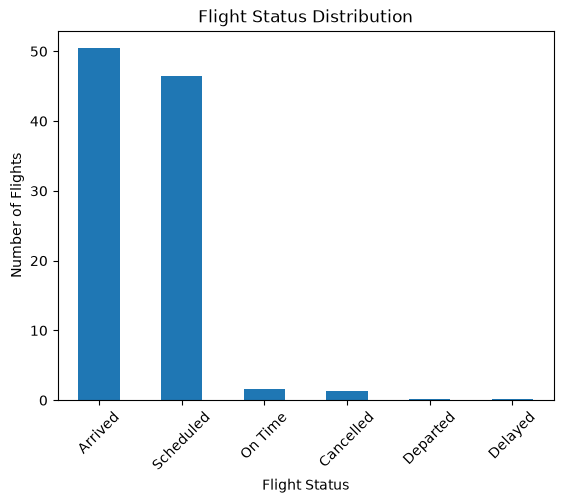

In [52]:
plt.Figure(figsize=(8,5))
(flights['status'].value_counts(normalize=True)*100).plot(kind='bar')
plt.title("Flight Status Distribution")
plt.xlabel("Flight Status")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.show()

### Inference

> `Arrived` has the highest count compared to other statuses.
> It tells that most of flights which departured are arrived.
> So I can use a more specific population for occupancy analysis instead of every scheduled flight.

## 12.2 Aircraft Range

### Question
How far can each aircraft type fly?

In [53]:
aircrafts[["aircraft_code", "model", "range"]].sort_values("range", ascending=False)

,aircraft_code,model,range
0,773,Boeing 777-300,11100
1,763,Boeing 767-300,7900
5,319,Airbus A319-100,6700
3,320,Airbus A320-200,5700
4,321,Airbus A321-200,5600
6,733,Boeing 737-300,4200
2,SU9,Sukhoi Superjet-100,3000
8,CR2,Bombardier CRJ-200,2700
7,CN1,Cessna 208 Caravan,1200


<Figure size 1000x500 with 0 Axes>

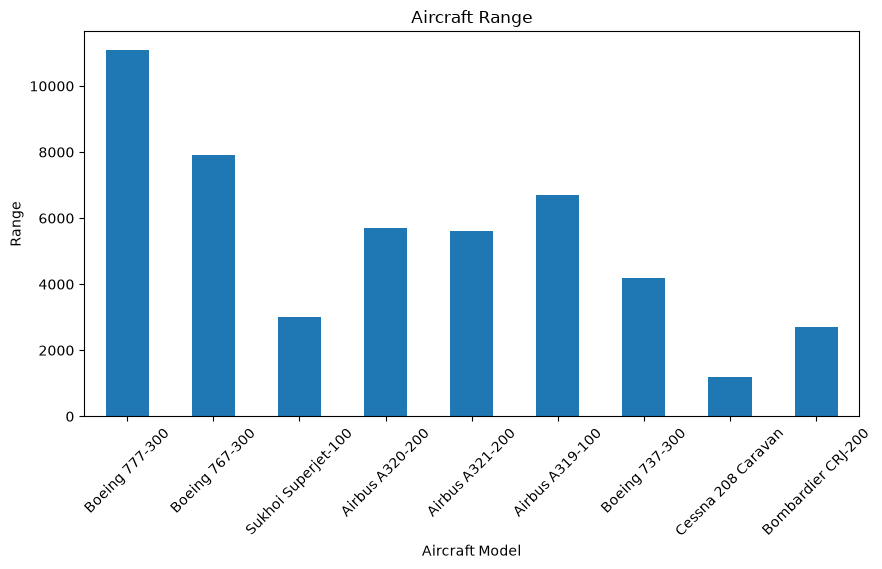

In [54]:
plt.figure(figsize=(10, 5))
aircrafts.plot(kind="bar", x="model", y="range", legend=False, figsize=(10, 5))
plt.title("Aircraft Range")
plt.xlabel("Aircraft Model")
plt.ylabel("Range")
plt.xticks(rotation=45)
plt.show()

> Boeing 777-300 aircraft has the greatest range.

> Range doesnt tell us about the occupancy. Range and Occupancy answer different business questions because Range describes how far an aircraft can operate and occupancy describes how much of its available seating capacity is used.

## 12.3 Aircrafts with More Than 100 Seats

### Question
Which aircraft types have more than 100 seats?

In [61]:
aircrafts_over_100 = aircraft_capacity[
    aircraft_capacity["total_seats"] > 100
].sort_values("total_seats", ascending=False)

aircrafts_over_100

,aircraft_code,total_seats
5,773,402
4,763,222
2,321,170
1,320,140
3,733,130
0,319,116


<Figure size 800x500 with 0 Axes>

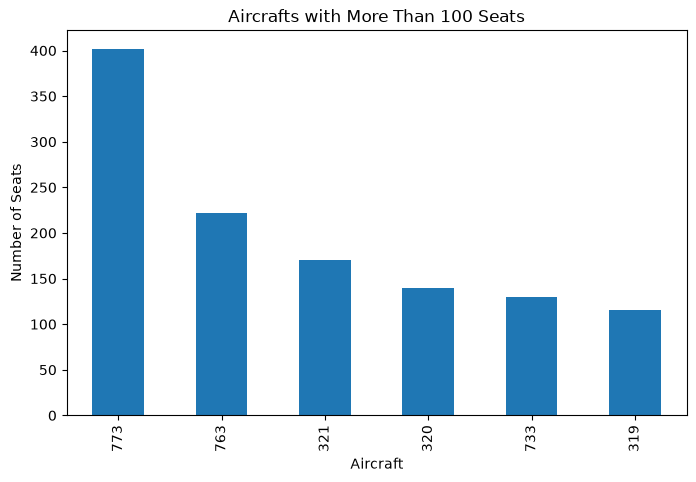

In [62]:
plt.figure(figsize=(8, 5))
aircrafts_over_100.plot(kind="bar", x="aircraft_code", y="total_seats", legend=False, figsize=(8, 5))
plt.title("Aircrafts with More Than 100 Seats")
plt.xlabel("Aircraft")
plt.ylabel("Number of Seats")
plt.show()

> Boeing 777-300 aircraft have the largest capacity.  

> Largest capacity doesnt mean advantage. Because when there is weak demand more seats will be empty which impacts the revenue.

## 12.4 Aircraft Flight Frequency

### Question
Which aircraft types are used most often?

In [63]:
aircraft_flight_count = (
    flight_data["aircraft_code"]
    .value_counts()
    .reset_index()
)

aircraft_flight_count.columns = ["aircraft_code", "flight_count"]
aircraft_flight_count

,aircraft_code,flight_count
0,CN1,9273
1,CR2,9048
2,SU9,8504
3,321,1952
4,733,1274
5,319,1239
6,763,1221
7,773,610


<Figure size 800x500 with 0 Axes>

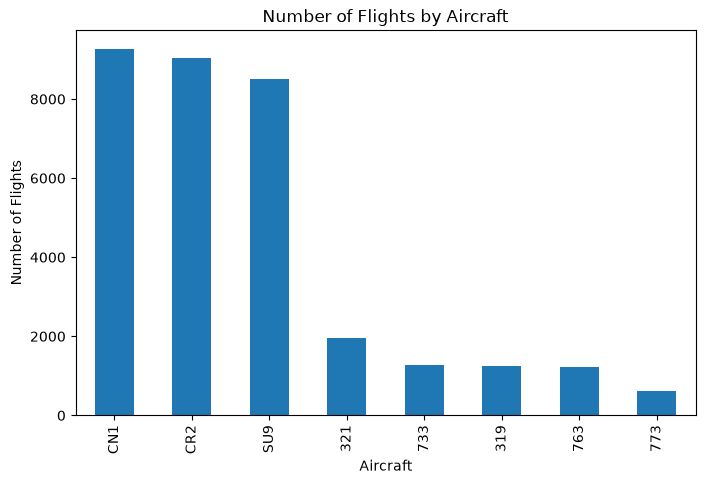

In [64]:
plt.figure(figsize=(8, 5))
aircraft_flight_count.plot(kind="bar", x="aircraft_code", y="flight_count", legend=False, figsize=(8, 5))
plt.title("Number of Flights by Aircraft")
plt.xlabel("Aircraft")
plt.ylabel("Number of Flights")
plt.show()

> Cessna 208 Caravan CN1 aircraft is used most often. 
> It means it has impact on improvement of revenue even though it has small occupancy, because it is used frequently.

## 12.5 Occupancy Distribution

### Question
What does the distribution of occupancy look like?

In [67]:
occupancy_data['occupancy_rate'].describe()

count    11518.000000
mean         0.513094
std          0.274440
min          0.004505
25%          0.280000
50%          0.500000
75%          0.752252
max          1.000000
Name: occupancy_rate, dtype: float64

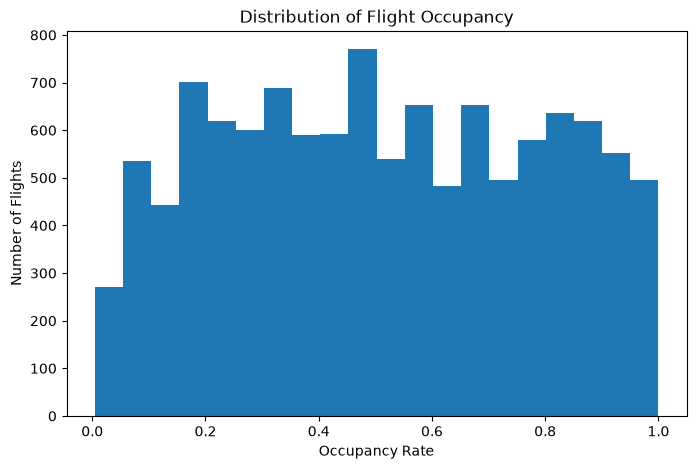

In [68]:
plt.figure(figsize=(8, 5))
plt.hist(occupancy_data["occupancy_rate"], bins=20)
plt.title("Distribution of Flight Occupancy")
plt.xlabel("Occupancy Rate")
plt.ylabel("Number of Flights")
plt.show()

> The median occupancy is 50%.  

> This means half of the flights operate with less than 50% of their seats filled, while the other half operate with more than 50% capacity.

> Looking at the overall distribution, flights are fairly evenly spread across all occupancy rates, showing that a significant number of flights are underutilized while others are heavily packed.

## 12.6 Fare Distribution

### Question
What does the distribution of ticket prices look like?

In [69]:
ticket_flights["amount"].describe()

count    1.045726e+06
mean     1.985891e+04
std      2.261239e+04
min      3.000000e+03
25%      7.200000e+03
50%      1.340000e+04
75%      2.310000e+04
max      2.033000e+05
Name: amount, dtype: float64

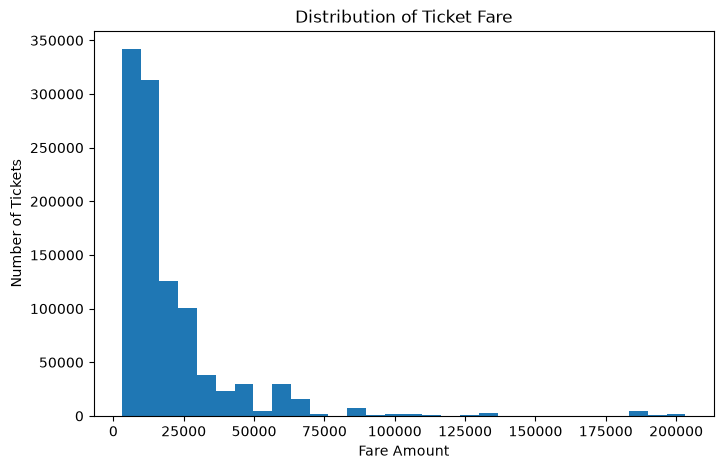

In [70]:
plt.figure(figsize=(8, 5))
plt.hist(ticket_flights["amount"], bins=30)
plt.title("Distribution of Ticket Fare")
plt.xlabel("Fare Amount")
plt.ylabel("Number of Tickets")
plt.show()

> The fare distribution is heavily right-skewed with a long tail.

> There are signs of very high fares.

> This tells that using one average fare for the whole business is not efficient.

## 12.7 Daily Number of Tickets Booked

The original analysis also examined how ticket bookings changed over time.

In [71]:
tickets_with_bookings = tickets.merge(
    bookings[["book_ref", "book_date"]],
    on="book_ref",
    how="left"
)

tickets_with_bookings["book_date_only"] = tickets_with_bookings["book_date"].dt.date

daily_tickets = (
    tickets_with_bookings.groupby("book_date_only")
    .size()
    .reset_index(name="tickets_booked")
)

daily_tickets.head()

,book_date_only,tickets_booked
0,2017-06-21,6
1,2017-06-22,12
2,2017-06-23,28
3,2017-06-24,106
4,2017-06-25,266


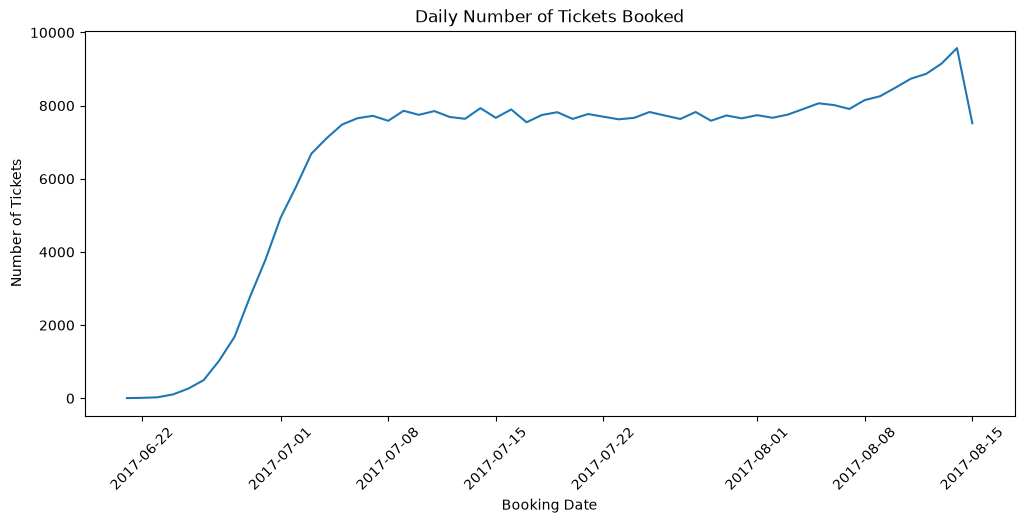

In [72]:
plt.figure(figsize=(12, 5))
plt.plot(daily_tickets["book_date_only"], daily_tickets["tickets_booked"])
plt.title("Daily Number of Tickets Booked")
plt.xlabel("Booking Date")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.show()

> Booking volume rises after some initial period like after end of june 2017 and were stable till starting of august month and went peak in mid of august 2017.

> need to monitor booking pace and should design targeted strategies (e.g., promotional pricing or promotions) specifically for early-stage or weaker historical periods to maximize revenue.

## 12.8 Daily Booking Value

The `bookings` table contains the total amount of each booking.

In [73]:
bookings["book_date_only"] = bookings["book_date"].dt.date

daily_booking_value = (
    bookings.groupby("book_date_only")
    .agg(total_booking_value=("total_amount", "sum"))
    .reset_index()
)

daily_booking_value.head()

,book_date_only,total_booking_value
0,2017-06-21,441900
1,2017-06-22,775300
2,2017-06-23,1822000
3,2017-06-24,5977000
4,2017-06-25,15305400


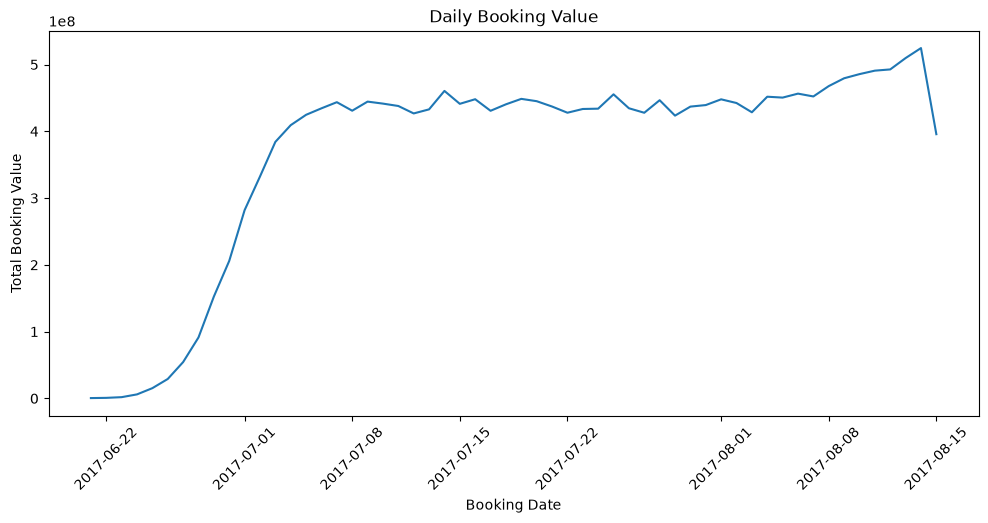

In [74]:
plt.figure(figsize=(12, 5))
plt.plot(daily_booking_value["book_date_only"], daily_booking_value["total_booking_value"])
plt.title("Daily Booking Value")
plt.xlabel("Booking Date")
plt.ylabel("Total Booking Value")
plt.xticks(rotation=45)
plt.show()

> booking value is positively correlated with booking volume.

> A day with higher booking volume can still yield lower total value because ticket prices vary significantly across different aircraft models and seat classes. 
> A surge in low-cost economy tickets generates less overall revenue than a small number of high-fare premium bookings.

# 13. BIVARIATE ANALYSIS

Bivariate analysis studies the relationship between **two variables**.

I will analyse:

1. aircraft vs occupancy
2. fare class vs average fare
3. fare vs occupancy
4. day of week vs occupancy
5. occupancy vs revenue
6. aircraft vs revenue

## 13.1 Aircraft vs Occupancy

In [76]:
aircraft_occupancy = (
    occupancy_data.groupby("aircraft_code")
    .agg(
        flights=("flight_id", "nunique"),
        seats=("total_seats", "sum"),
        passengers=("boarded_passengers", "sum")
    )
    .reset_index()
)

aircraft_occupancy["occupancy_rate"] = (
    aircraft_occupancy["passengers"] /
    aircraft_occupancy["seats"]
)

aircraft_occupancy.sort_values("occupancy_rate")

,aircraft_code,flights,seats,passengers,occupancy_rate
6,CR2,3906,195300,83912.0,0.429657
0,319,547,63452,29310.0,0.461924
5,CN1,1354,16248,8130.0,0.500369
3,763,606,134532,69046.0,0.513231
1,321,650,110500,57726.0,0.522407
7,SU9,3550,344350,201683.0,0.585692
2,733,595,77350,47752.0,0.617350
4,773,310,124620,82127.0,0.659019


<Figure size 800x500 with 0 Axes>

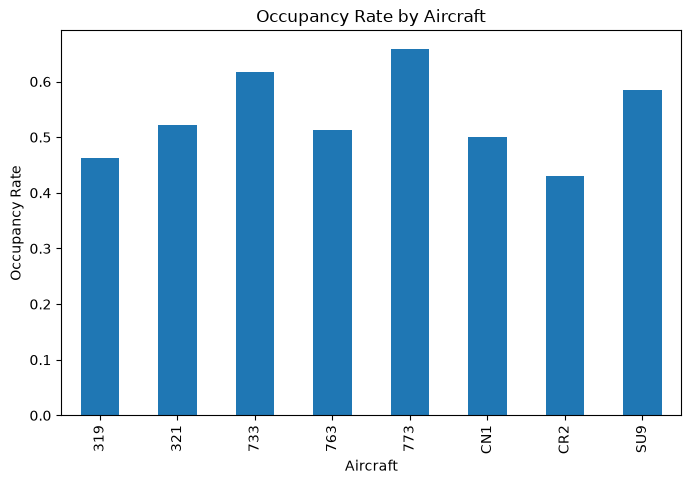

In [77]:
plt.figure(figsize=(8, 5))
aircraft_occupancy.plot(kind="bar", x="aircraft_code", y="occupancy_rate", legend=False, figsize=(8, 5))
plt.title("Occupancy Rate by Aircraft")
plt.xlabel("Aircraft")
plt.ylabel("Occupancy Rate")
plt.show()

> Bombardier CRJ-200 (CR2) aircraft has the lowest occupancy. 

> Boeing 777-300 (773) has the highest occupancy.

> aircraft type appear to matter for seat utilisation.
> This indicates that seat utilisation is not uniform. The business should investigate the routes, schedules, demand and fare mix associated with lower-occupancy aircraft before changing aircraft allocation.

## 13.2 Fare Class vs Average Fare

The `ticket_flights` table contains fare conditions such as Economy, Comfort and Business.

In [78]:
fare_analysis = (
    ticket_flights
    .merge(
        flights[["flight_id", "aircraft_code"]],
        on="flight_id",
        how="left"
    )
    .groupby(["aircraft_code", "fare_conditions"])
    .agg(
        tickets=("ticket_no", "count"),
        average_fare=("amount", "mean"),
        total_revenue=("amount", "sum")
    )
    .reset_index()
)

fare_analysis

,aircraft_code,fare_conditions,tickets,average_fare,total_revenue
0,319,Business,9055,113550.557703,1028200300
1,319,Economy,43798,38311.402347,1677962800
2,321,Business,17573,34435.662664,605137900
3,321,Economy,89556,11534.974764,1033026200
4,733,Business,7977,41865.626175,333962100
5,733,Economy,78125,13985.152000,1092590000
6,763,Business,16801,82839.842866,1391792200
7,763,Economy,107973,27594.721829,2979484900
8,773,Business,10821,57779.909435,625236400
9,773,Comfort,17291,32740.552889,566116900


<Figure size 1000x600 with 0 Axes>

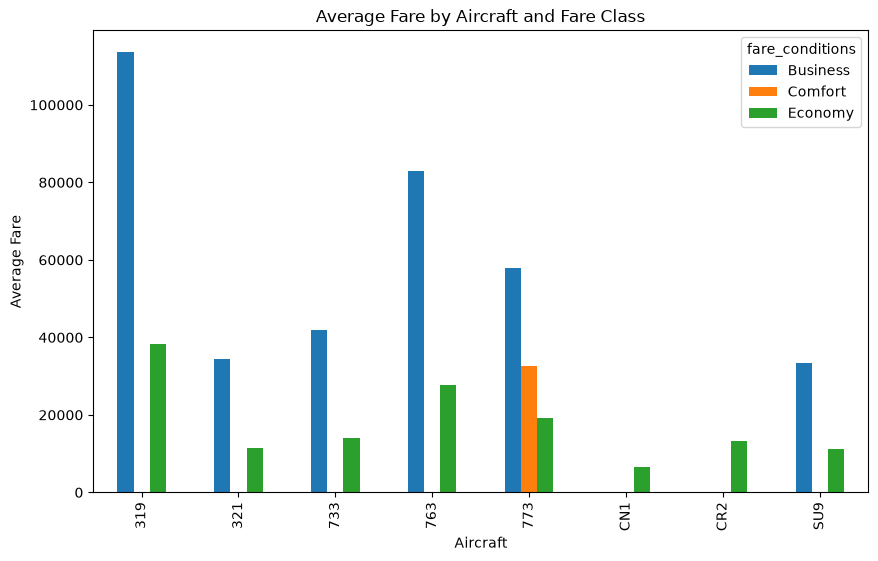

In [79]:
plt.figure(figsize=(10, 6))
fare_pivot = fare_analysis.pivot(index="aircraft_code", columns="fare_conditions", values="average_fare")
fare_pivot.plot(kind="bar", figsize=(10, 6))
plt.title("Average Fare by Aircraft and Fare Class")
plt.xlabel("Aircraft")
plt.ylabel("Average Fare")
plt.show()

In [81]:
seat_class_count = (
    seats.groupby(["aircraft_code", "fare_conditions"])
    .size()
    .reset_index(name="seat_count")
)

seat_class_count

,aircraft_code,fare_conditions,seat_count
0,319,Business,20
1,319,Economy,96
2,320,Business,20
3,320,Economy,120
4,321,Business,28
5,321,Economy,142
6,733,Business,12
7,733,Economy,118
8,763,Business,30
9,763,Economy,192


> Premium fare classes generate higher revenue per passenger than Economy in the observed data. Therefore, the airline should not rely only on increasing passenger volume through blanket discounts; it should also protect premium yield where demand supports it.

## 13.3 Average Fare vs Occupancy

In [82]:
fare_occupancy = occupancy_data[
    ["average_fare", "occupancy_rate"]
].dropna()

fare_occupancy.corr()

,average_fare,occupancy_rate
average_fare,1.000000,-0.103754
occupancy_rate,-0.103754,1.000000


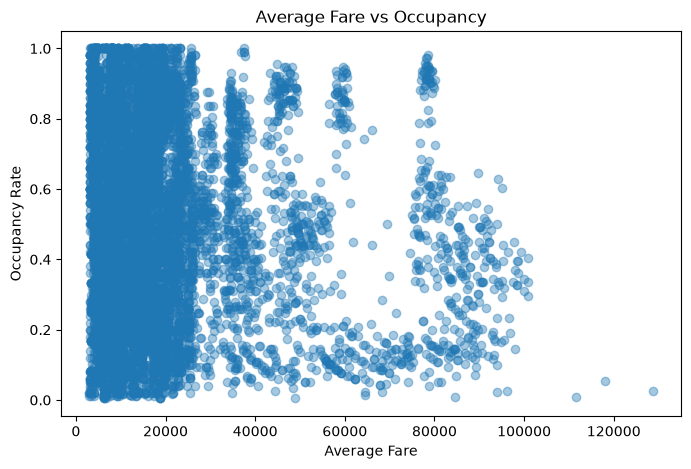

In [83]:
plt.figure(figsize=(8, 5))
plt.scatter(fare_occupancy["average_fare"], fare_occupancy["occupancy_rate"], alpha=0.4)
plt.title("Average Fare vs Occupancy")
plt.xlabel("Average Fare")
plt.ylabel("Occupancy Rate")
plt.show()

> Average fare alone does not explain occupancy in this dataset. Route, aircraft type, fare class and timing should also be considered. The observed correlation is an association, not proof that changing price will cause occupancy to change.

## 13.4 Day of Week vs Occupancy

In [84]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_occupancy = (
    occupancy_data.groupby("day_name")
    .agg(
        flights=("flight_id", "nunique"),
        occupancy_rate=("occupancy_rate", "mean")
    )
    .reset_index()
)

day_occupancy["day_name"] = pd.Categorical(
    day_occupancy["day_name"],
    categories=day_order,
    ordered=True
)

day_occupancy = day_occupancy.sort_values("day_name")
day_occupancy

,day_name,flights,occupancy_rate
1,Monday,1791,0.511191
5,Tuesday,1891,0.520123
6,Wednesday,1482,0.507783
4,Thursday,1522,0.513279
0,Friday,1412,0.533884
2,Saturday,1567,0.517412
3,Sunday,1853,0.492365


<Figure size 1000x500 with 0 Axes>

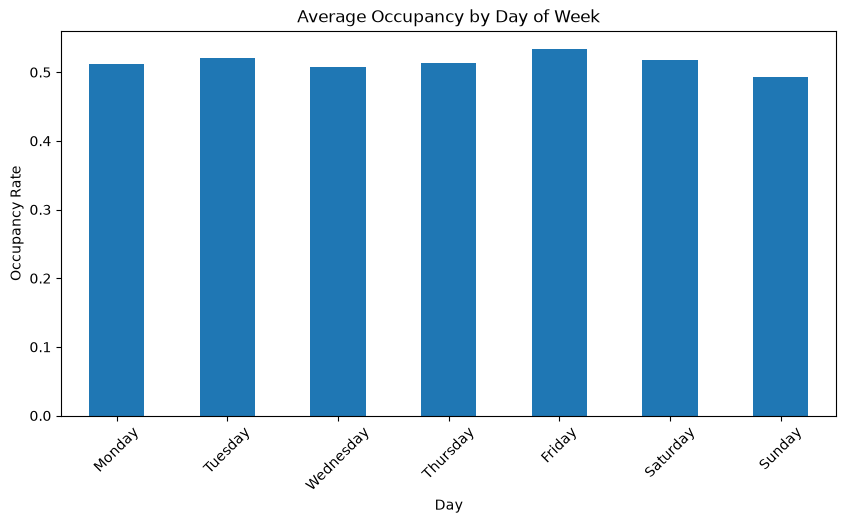

In [85]:
plt.figure(figsize=(10, 5))
day_occupancy.plot(kind="bar", x="day_name", y="occupancy_rate", legend=False, figsize=(10, 5))
plt.title("Average Occupancy by Day of Week")
plt.xlabel("Day")
plt.ylabel("Occupancy Rate")
plt.xticks(rotation=45)
plt.show()

> Occupancy varies by day of week in the observed analysis. Wednesday and Thursday were lower than the other days in the previous output, while Tuesday was higher. However, the corrected notebook should be rerun using only flights with an observed boarding record before treating the exact percentages as final.

## 13.5 Occupancy vs Ticket Revenue

In [86]:
revenue_occupancy = flight_data[
    ["occupancy_rate", "ticket_revenue"]
].dropna()

revenue_occupancy.corr()

,occupancy_rate,ticket_revenue
occupancy_rate,1.00000,0.28284
ticket_revenue,0.28284,1.00000


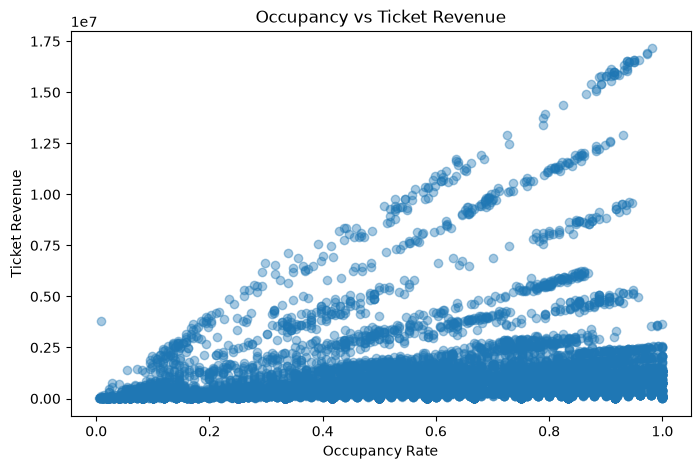

In [87]:
plt.figure(figsize=(8, 5))
plt.scatter(revenue_occupancy["occupancy_rate"], revenue_occupancy["ticket_revenue"], alpha=0.4)
plt.title("Occupancy vs Ticket Revenue")
plt.xlabel("Occupancy Rate")
plt.ylabel("Ticket Revenue")
plt.show()

>At a general level, more occupied seats create more opportunities to earn ticket revenue, but total revenue also depends on:

- average fare
- fare mix
- aircraft capacity
- flight frequency
- route mix

> Therefore, occupancy should not be used alone to judge commercial performance.

> A useful metric is **revenue per available seat** because it combines revenue with the amount of capacity offered.

**Inference:** A route can have high occupancy but moderate yield, while another route can have lower occupancy but stronger revenue per available seat. This is why the business should monitor both utilisation and yield.

## 13.6 Aircraft vs Revenue

In [88]:
revenue_by_aircraft = (
    flight_data.groupby("aircraft_code")
    .agg(
        ticket_count=("ticket_count", "sum"),
        total_revenue=("ticket_revenue", "sum")
    )
    .reset_index()
)

revenue_by_aircraft["avg_revenue_per_ticket"] = (
    revenue_by_aircraft["total_revenue"] /
    revenue_by_aircraft["ticket_count"]
)

revenue_by_aircraft = revenue_by_aircraft.merge(
    aircrafts[["aircraft_code", "model"]],
    on="aircraft_code",
    how="left"
)

revenue_by_aircraft.sort_values("total_revenue", ascending=False)

,aircraft_code,ticket_count,total_revenue,avg_revenue_per_ticket,model
7,SU9,365698.0,5.114485e+09,13985.541895,Sukhoi Superjet-100
3,763,124774.0,4.371277e+09,35033.557472,Boeing 767-300
4,773,144376.0,3.431206e+09,23765.760930,Boeing 777-300
0,319,52853.0,2.706163e+09,51201.693376,Airbus A319-100
6,CR2,150122.0,1.982760e+09,13207.661102,Bombardier CRJ-200
1,321,107129.0,1.638164e+09,15291.509302,Airbus A321-200
2,733,86102.0,1.426552e+09,16568.164503,Boeing 737-300
5,CN1,14672.0,9.637380e+07,6568.552345,Cessna 208 Caravan


<Figure size 900x500 with 0 Axes>

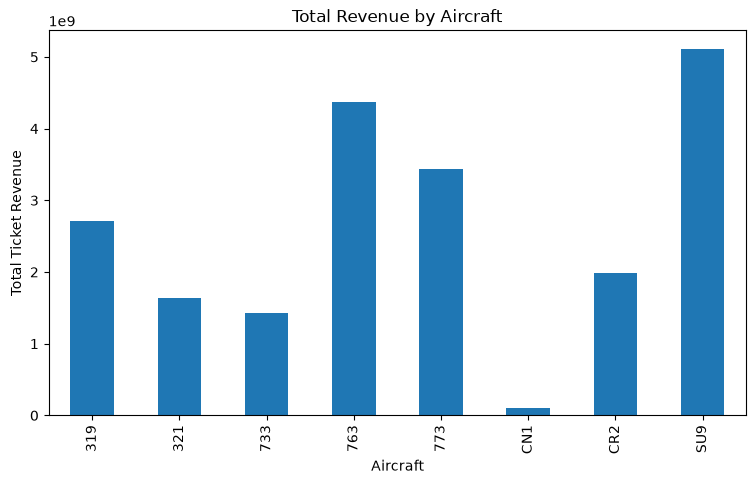

In [89]:
plt.figure(figsize=(9, 5))
revenue_by_aircraft.plot(kind="bar", x="aircraft_code", y="total_revenue", legend=False, figsize=(9, 5))
plt.title("Total Revenue by Aircraft")
plt.xlabel("Aircraft")
plt.ylabel("Total Ticket Revenue")
plt.show()

### Highest total revenue
**SU9** with approximately **5.114 billion** in ticket revenue during the dataset period.

### Does highest revenue mean highest occupancy?
No. SU9 has approximately **58.6%** occupancy, while 773 has the highest occupancy at **65.9%**.

### Why not call one aircraft “best”?
Because different metrics answer different questions. SU9 has the highest total revenue, 773 has the highest occupancy, and A319 has the highest average revenue per ticket among the aircraft-level totals above. Each reflects a different dimension of performance.

### Inference
> SU9 generates the highest total ticket revenue in the observed dataset. This result should be interpreted alongside ticket volume, average fare, aircraft capacity, flight frequency and occupancy rather than attributing the difference to a single cause.

# 14. MULTIVARIATE ANALYSIS

multivariate analysis can simply mean looking at **three or more business dimensions together**.

I will use:

- route + aircraft + occupancy
- route + aircraft + revenue per available seat

## 14.1 Route + Aircraft + Occupancy

A route may have low occupancy because of the route itself, the aircraft assigned to it, or both.

In [90]:
route_analysis = (
    occupancy_data
    .groupby(["route", "aircraft_code"])
    .agg(
        flights=("flight_id", "nunique"),
        seats=("total_seats", "sum"),
        passengers=("boarded_passengers", "sum"),
        empty_seats=("empty_seats", "sum")
    )
    .reset_index()
)

route_analysis["occupancy_rate"] = (
    route_analysis["passengers"] /
    route_analysis["seats"]
)

route_analysis.sort_values("occupancy_rate").head(20)

,route,aircraft_code,flights,seats,passengers,empty_seats,occupancy_rate
198,MJZ -> IKT,CR2,29,1450,65.0,1385.0,0.044828
269,OVS -> UFA,CR2,31,1550,84.0,1466.0,0.054194
374,TJM -> UCT,CR2,18,900,49.0,851.0,0.054444
381,UCT -> TJM,CR2,14,700,48.0,652.0,0.068571
234,NOZ -> KRR,733,3,390,30.0,360.0,0.076923
289,RGK -> SVO,733,3,390,35.0,355.0,0.089744
158,KRR -> NOZ,733,4,520,47.0,473.0,0.090385
107,GDX -> SCW,763,4,888,85.0,803.0,0.095721
261,OVB -> SGC,CR2,31,1550,150.0,1400.0,0.096774
302,SGC -> OVB,CR2,31,1550,151.0,1399.0,0.097419


> A route-aircraft combination with low occupancy, repeated operations and many empty seats is a stronger candidate for investigation than a route with low occupancy on only one flight.

## 14.2 Route + Aircraft + Revenue per Available Seat

Occupancy should not be the only performance measure.

In [91]:
route_revenue = (
    flight_data
    .groupby(["route", "aircraft_code"])
    .agg(
        flights=("flight_id", "nunique"),
        seats=("total_seats", "sum"),
        revenue=("ticket_revenue", "sum"),
        occupancy_rate=("occupancy_rate", "mean")
    )
    .reset_index()
)

route_revenue["revenue_per_available_seat"] = (
    route_revenue["revenue"] /
    route_revenue["seats"]
)

route_revenue.sort_values(
    "revenue_per_available_seat",
    ascending=False
).head(20)

,route,aircraft_code,flights,seats,revenue,occupancy_rate,revenue_per_available_seat
82,DME -> KHV,763,61,13542,753478300.0,0.839940,55640.104859
195,KHV -> DME,763,61,13542,733797800.0,0.747167,54186.811402
257,LED -> IKT,321,61,10370,411603000.0,0.826186,39691.706847
171,IKT -> LED,321,61,10370,404050300.0,0.640196,38963.384764
197,KHV -> LED,763,61,13542,507672400.0,0.453211,37488.731354
258,LED -> KHV,763,61,13542,498750700.0,0.526446,36829.914341
55,CNN -> DME,319,9,1044,36478500.0,0.501724,34941.091954
492,SVO -> UUS,319,61,7076,236573200.0,0.449666,33433.182589
170,IKT -> KZN,319,61,7076,233003200.0,0.712736,32928.660260
242,KZN -> IKT,319,61,7076,232862000.0,0.767529,32908.705483


> These values show why occupancy and revenue-per-available-seat can tell different stories. For example, DME → KHV has only about 
> 41.3% occupancy but very high revenue per available seat in the old output.

# 15. LOW-OCCUPANCY OPPORTUNITY ANALYSIS

Now turning EDA into a business question:

> Which repeated route-aircraft combinations have relatively low occupancy and therefore deserve further investigation?

We will use a simple rule:

- at least 10 observed flights
- occupancy below the median occupancy in the route dataset

In [92]:
median_occupancy = route_analysis["occupancy_rate"].median()

opportunities = route_analysis[
    (route_analysis["flights"] >= 10) &
    (route_analysis["occupancy_rate"] < median_occupancy)
].copy()

opportunities = opportunities.sort_values(
    ["occupancy_rate", "empty_seats"]
)

opportunities.head(20)

,route,aircraft_code,flights,seats,passengers,empty_seats,occupancy_rate
198,MJZ -> IKT,CR2,29,1450,65.0,1385.0,0.044828
269,OVS -> UFA,CR2,31,1550,84.0,1466.0,0.054194
374,TJM -> UCT,CR2,18,900,49.0,851.0,0.054444
381,UCT -> TJM,CR2,14,700,48.0,652.0,0.068571
261,OVB -> SGC,CR2,31,1550,150.0,1400.0,0.096774
302,SGC -> OVB,CR2,31,1550,151.0,1399.0,0.097419
449,YKS -> LED,319,31,3596,352.0,3244.0,0.097887
193,LED -> YKS,319,30,3480,351.0,3129.0,0.100862
199,MJZ -> OVB,CR2,31,1550,170.0,1380.0,0.109677
406,UUD -> VKO,319,13,1508,191.0,1317.0,0.126658


### Inference
> These route-aircraft combinations have repeated observations and relatively low occupancy. They are candidates for further investigation, not automatically bad or unprofitable routes.

### Why use a minimum number of flights?
A route with one or two observations can produce an unstable result. Requiring repeated observations gives the analyst more evidence before recommending action.

# 16. 10% OCCUPANCY IMPROVEMENT SCENARIO

The original SQL case study asked:

> What happens if every aircraft achieves a 10% higher occupancy rate?

Here we reproduce the scenario using pandas.

### Important assumption

This is a **simple revenue sensitivity scenario**.

It assumes that revenue rises in proportion to occupancy and that the average yield stays unchanged.

It is **not a profit forecast**.

In [93]:
aircraft_scenario = (
    aircraft_occupancy.merge(
        revenue_by_aircraft[["aircraft_code", "total_revenue"]],
        on="aircraft_code",
        how="left"
    )
)

aircraft_scenario["new_occupancy_rate"] = (
    aircraft_scenario["occupancy_rate"] * 1.10
)

aircraft_scenario["estimated_revenue"] = (
    aircraft_scenario["total_revenue"] *
    (aircraft_scenario["new_occupancy_rate"] /
     aircraft_scenario["occupancy_rate"])
)

aircraft_scenario["additional_revenue"] = (
    aircraft_scenario["estimated_revenue"] -
    aircraft_scenario["total_revenue"]
)

aircraft_scenario[[
    "aircraft_code",
    "occupancy_rate",
    "new_occupancy_rate",
    "total_revenue",
    "additional_revenue"
]]

,aircraft_code,occupancy_rate,new_occupancy_rate,total_revenue,additional_revenue
0,319,0.461924,0.508116,2.706163e+09,270616310.0
1,321,0.522407,0.574648,1.638164e+09,163816410.0
2,733,0.617350,0.679085,1.426552e+09,142655210.0
3,763,0.513231,0.564554,4.371277e+09,437127710.0
4,773,0.659019,0.724921,3.431206e+09,343120550.0
5,CN1,0.500369,0.550406,9.637380e+07,9637380.0
6,CR2,0.429657,0.472623,1.982760e+09,198276050.0
7,SU9,0.585692,0.644261,5.114485e+09,511448470.0


### Largest additional revenue sensitivity
> **SU9**, because it has the largest current revenue base.

### Total dataset-period sensitivity
> Current ticket revenue ≈ **20,766,980,900**. A 10% proportional uplift gives approximately **2,076,698,090** additional revenue, producing a scenario revenue of about **22,843,678,990**.

### Inference
> This is a **revenue sensitivity**, not a profit forecast. It assumes average yield remains unchanged and that the additional seats can actually be sold. The dataset does not contain fuel, labour, tax, maintenance, leasing or financing costs. Therefore, the extra revenue cannot be called extra profit.

> Aircraft occupancy varies substantially, from about 43.0% for the Bombardier CRJ-200 to 65.9% for the Boeing 777-300.
> This means some aircraft are operating with a much larger share of unused seats, while others are being utilized more effectively.
> The airline should investigate the routes, schedules, pricing and demand patterns associated with lower-occupancy aircraft before making changes to aircraft allocation.

# 18. Final Business Questions

### Question 1 — Which aircraft types have the highest and lowest occupancy?
**Highest:** 773 at about **65.9%**.  
**Lowest:** CR2 at about **43.0%**.

**Inference:** Occupancy differs materially across aircraft, so utilisation should be investigated by aircraft and route rather than using one fleet-wide assumption.

### Question 2 — Which aircraft types have the greatest available capacity?
**773** has the largest capacity at **402 seats**, followed by **763** at **222 seats** and **321** at **170 seats**.

**Inference:** Large-capacity aircraft create greater absolute empty-seat exposure when demand is weak.

### Question 3 — Does the most frequently used aircraft also have the highest occupancy?
No. **CN1** is the most frequently used in the executed flight table with **9,273 flights**, but **773** has the highest occupancy at about **65.9%**.

**Inference:** Frequency and utilisation need to be analysed together.

### Question 4 — How does fare class affect average fare?
Business generally has a higher average fare than Economy where both are available. The 773 also has a Comfort class. Aircraft differ in their fare-class mix.

**Inference:** Pricing should be segmented by fare class and aircraft rather than based on one average fare.

### Question 5 — Is average fare strongly related to occupancy?
No. The observed correlation is about **-0.049**, indicating a very weak linear relationship.

**Inference:** Average fare alone does not explain occupancy. Other variables and controlled pricing tests are needed.

### Question 6 — Does occupancy vary by day of week?
Yes, the earlier execution showed variation across days. The previous numbers should not be treated as final corrected estimates because that version converted missing boarding observations to zero.

**Inference:** Day-level differences are worth investigating, but the corrected occupancy population should be used before making operational decisions.

### Question 7 — Which aircraft generates the most ticket revenue?
**SU9**, with about **5.114 billion** in ticket revenue for the dataset period.

**Inference:** SU9 has the largest observed revenue base, but revenue alone does not establish that it is the strongest aircraft on every dimension.

### Question 8 — Which route-aircraft combinations appear to have the greatest unused capacity?
The corrected final answer must come from the final `route_analysis` output using only observed boarding records. The older output is contaminated by missing-boarding rows converted to zero.

**Correct inference:** prioritise repeated route-aircraft combinations with low occupancy and large empty-seat capacity.

### Question 9 — Which route-aircraft combinations should the business investigate first?
Use the simple rule: **at least 10 observed flights + occupancy below the route median**. Then sort by empty seats.

**Inference:** This produces a shortlist for investigation, not a definitive list of bad routes.

### Question 10 — What does the 10% occupancy scenario suggest?
A 10% relative occupancy improvement produces a proportional revenue sensitivity if average yield stays constant. SU9 has the largest absolute additional-revenue sensitivity because it already has the largest revenue base.

**Inference:** Occupancy improvement can have material revenue potential, but the scenario does not prove that the uplift is achievable or profitable.

# 19. Write a short business recommendation of 5–8 lines.
> The analysis shows that occupancy varies substantially across aircraft, with CR2 at about 43.0% and 773 at about 65.9%. The airline should therefore avoid a single fleet-wide strategy. Aircraft frequency and capacity should be considered together with occupancy because frequently operated aircraft can create substantial cumulative unused capacity. Fare analysis shows strong differences between Economy and premium classes, so blanket discounting may weaken yield. Route-aircraft combinations with repeated low occupancy should be investigated using booking pace, route demand and aircraft allocation. The airline can test targeted pricing or schedule interventions on selected weak-demand segments while monitoring occupancy and revenue per available seat. However, the 10% uplift is only a revenue sensitivity and not a profit forecast because operating-cost data are not available.

# 20. Exporting the Main Analysis Tables

Saving the outputs so that they can be reused in Excel, Power BI or a presentation.

In [94]:
import os

output_folder = "eda_outputs"

os.makedirs(output_folder, exist_ok=True)


In [95]:
aircraft_capacity.to_csv(os.path.join(output_folder, "aircraft_capacity.csv"), index=False)
aircraft_flight_count.to_csv(os.path.join(output_folder, "aircraft_flight_count.csv"), index=False)
aircraft_occupancy.to_csv(os.path.join(output_folder, "aircraft_occupancy.csv"), index=False)
fare_analysis.to_csv(os.path.join(output_folder, "fare_analysis.csv"), index=False)
seat_class_count.to_csv(os.path.join(output_folder, "seat_class_count.csv"), index=False)
daily_tickets.to_csv(os.path.join(output_folder, "daily_tickets.csv"), index=False)
daily_booking_value.to_csv(os.path.join(output_folder, "daily_booking_value.csv"), index=False)
revenue_by_aircraft.to_csv(os.path.join(output_folder, "revenue_by_aircraft.csv"), index=False)
route_analysis.to_csv(os.path.join(output_folder, "route_analysis.csv"), index=False)
route_revenue.to_csv(os.path.join(output_folder, "route_revenue.csv"), index=False)
opportunities.to_csv(os.path.join(output_folder, "low_occupancy_opportunities.csv"), index=False)
aircraft_scenario.to_csv(os.path.join(output_folder, "occupancy_10_percent_scenario.csv"), index=False)

day_occupancy.to_csv(os.path.join(output_folder, "day_occupancy.csv"), index=False)

print("Analysis CSV files saved to:", output_folder)

Analysis CSV files saved to: eda_outputs
